# Week 3 — Tuned LightGBM: Direct vs. Recursive, Revisited

`notebooks/06_lightgbm_horizons.ipynb` compared direct-per-horizon vs. recursive LightGBM using fixed default hyperparameters for all four models. This notebook tunes each of the four **direct** models properly, then re-runs the recursive strategy on top of the *tuned* `30min` model (previously it was rolling forward an untuned one) — so the direct-vs-recursive comparison is now apples-to-apples at each model's best setting, not each model's default setting.

**Tuning methodology (the part worth getting right):** hyperparameters are selected via **walk-forward CV entirely inside `TRAIN`** (2020-2023) — train on 2020, validate on 2021; train on 2020-2021, validate on 2022; train on 2020-2022, validate on 2023 (`edf.models.tuning.walk_forward_cv_folds`). Each candidate's tree count is chosen by early stopping *within each CV fold*, and the final model's `n_estimators` is fixed from the average stopped iteration across folds — `VALIDATION` (2024) is never touched during search, including for picking how many trees to grow. Early-stopping directly against `VALIDATION` would let the exact set used for final reporting quietly influence model selection.

**New metrics this round** (`edf.evaluate`): `bias` (mean signed error — catches systematic over/under-forecasting that MAE/RMSE can't see) and `p95_abs_error` (a cheap tail-risk read, ahead of Week 6's extreme-event work). Training/tuning wall-clock time is also recorded, since direct-vs-recursive is a cost trade-off as well as an accuracy one.

In [1]:
import time

import matplotlib.pyplot as plt
import pandas as pd

from edf import config
from edf.models.baselines import previous_week_same_time
from edf.evaluate import evaluate
from edf.features.demand import build_feature_table
from edf.models.forecast import recursive_forecast, train_lightgbm
from edf.tracking import log_model_run
from edf.models.tuning import tune_lightgbm, walk_forward_cv_folds

pd.options.display.float_format = "{:.3f}".format

2026/09/07 09:31:24 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at /Users/sidonio.silva/RiderProjects/Personal/energy_demand_forecast/.venv/lib/python3.11/site-packages/mlflow/assistant/skills/instrumenting-with-mlflow-tracing/SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


In [2]:
df = pd.read_parquet("../data/processed/gb_energy_2020_2025.parquet")
demand = df["demand"]
train_start, train_end = config.TRAIN
val_start, val_end = config.VALIDATION
val_index = demand.loc[val_start:val_end].index

seasonal_naive_val = previous_week_same_time(demand).loc[val_start:val_end]
naive_mae = evaluate(demand.loc[val_start:val_end], seasonal_naive_val)["mae"]
naive_mae

2027.9001024590164

## Tune + train the final direct model, per horizon

In [3]:
tuned_models = {}
all_trials = {}
records = []
predictions_by_scenario = {}

for horizon_name, periods in config.HORIZONS.items():
    X, y = build_feature_table(df, horizon_periods=periods)
    X_train, y_train = X.loc[train_start:train_end], y.loc[train_start:train_end]
    X_val, y_val = X.loc[val_start:val_end], y.loc[val_start:val_end]

    cv_folds = walk_forward_cv_folds(X_train.index)
    t0 = time.time()
    best_params, best_n_estimators, trials = tune_lightgbm(X_train, y_train, cv_folds, n_trials=10)
    tune_seconds = time.time() - t0
    all_trials[horizon_name] = trials

    t0 = time.time()
    model = train_lightgbm(X_train, y_train, n_estimators=best_n_estimators, **best_params)
    train_seconds = time.time() - t0
    tuned_models[horizon_name] = model

    preds = pd.Series(model.predict(X_val), index=X_val.index)
    metrics = evaluate(y_val, preds, seasonal_naive_mae=naive_mae)
    metrics.update(horizon=horizon_name, strategy="direct", tune_seconds=tune_seconds, train_seconds=train_seconds)
    records.append(metrics)
    predictions_by_scenario[(horizon_name, "direct")] = preds

    log_model_run(
        horizon_name=horizon_name,
        horizon_periods=periods,
        model_name="lightgbm",
        fold_metrics=pd.DataFrame([metrics], index=pd.Index([2024], name="year")),
        extra_tags={"strategy": "direct", "tuned": "true"},
        extra_params={**best_params, "n_estimators": best_n_estimators},
        extra_metrics={"tune_seconds": tune_seconds, "train_seconds": train_seconds},
    )
    print(f"{horizon_name}: best={best_params}, n_estimators={best_n_estimators}, "
          f"tune={tune_seconds:.0f}s, train={train_seconds:.1f}s, MASE={metrics['mase']:.3f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000661 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4670
[LightGBM] [Info] Number of data points in the train set: 16224, number of used features: 25
[LightGBM] [Info] Start training from score 26689.268553


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000814 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4671
[LightGBM] [Info] Number of data points in the train set: 33744, number of used features: 25
[LightGBM] [Info] Start training from score 27549.082918


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000966 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4671
[LightGBM] [Info] Number of data points in the train set: 51264, number of used features: 25
[LightGBM] [Info] Start training from score 27232.341546


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000641 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4670
[LightGBM] [Info] Number of data points in the train set: 16224, number of used features: 25
[LightGBM] [Info] Start training from score 26689.268553


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000761 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4671
[LightGBM] [Info] Number of data points in the train set: 33744, number of used features: 25
[LightGBM] [Info] Start training from score 27549.082918


...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000579 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3650
[LightGBM] [Info] Number of data points in the train set: 16224, number of used features: 21
[LightGBM] [Info] Start training from score 26689.268553


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000664 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3651
[LightGBM] [Info] Number of data points in the train set: 33744, number of used features: 21
[LightGBM] [Info] Start training from score 27549.082918


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000824 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3651
[LightGBM] [Info] Number of data points in the train set: 51264, number of used features: 21
[LightGBM] [Info] Start training from score 27232.341546


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000961 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3652
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 21
[LightGBM] [Info] Start training from score 26931.631382


7d: best={'num_leaves': 31, 'min_child_samples': 20, 'learning_rate': 0.05}, n_estimators=92, tune=51s, train=0.8s, MASE=0.754


## Recursive strategy: roll the *tuned* `30min` model forward

In [4]:
base_model = tuned_models["30min"]

for horizon_name, periods in config.HORIZONS.items():
    if periods == 1:
        continue
    t0 = time.time()
    issue_times = val_index - pd.Timedelta(minutes=30 * periods)
    preds = recursive_forecast(base_model, df, issue_times, horizon_periods=periods)
    predict_seconds = time.time() - t0
    y_val = demand.loc[preds.index]

    metrics = evaluate(y_val, preds, seasonal_naive_mae=naive_mae)
    metrics.update(horizon=horizon_name, strategy="recursive", predict_seconds=predict_seconds)
    records.append(metrics)
    predictions_by_scenario[(horizon_name, "recursive")] = preds

    log_model_run(
        horizon_name=horizon_name,
        horizon_periods=periods,
        model_name="lightgbm",
        fold_metrics=pd.DataFrame(
            [{k: v for k, v in metrics.items() if k not in ("horizon", "strategy")}],
            index=pd.Index([2024], name="year"),
        ),
        extra_tags={"strategy": "recursive", "tuned": "true"},
        extra_metrics={"predict_seconds": predict_seconds},
    )
    print(f"{horizon_name} recursive: {predict_seconds:.1f}s, MASE={metrics['mase']:.3f}")

1h recursive: 0.2s, MASE=0.167


1d recursive: 6.7s, MASE=0.652


7d recursive: 40.0s, MASE=0.863


## Comparison table: tuned direct vs. tuned recursive, all metrics

In [5]:
results = pd.DataFrame(records).set_index(["horizon", "strategy"]).sort_index()
results[["mae", "rmse", "mape", "mase", "bias", "p95_abs_error"]]

mae     rmse  mape  mase     bias  p95_abs_error
horizon strategy                                                       
1d      direct    1229.621 1636.801 4.801 0.606  -55.697       3416.441
        recursive 1322.063 1746.455 5.183 0.652  -47.750       3631.394
1h      direct     365.829  480.967 1.405 0.180    2.798        993.825
        recursive  337.757  443.306 1.303 0.167   -2.431        908.937
30min   direct     207.326  271.259 0.803 0.102   -1.131        552.221
7d      direct    1528.025 2012.894 5.895 0.754 -116.097       4101.781
        recursive 1750.486 2388.175 6.651 0.863  -21.760       5133.458

## Before/after: does tuning actually move the needle?

Reference values below are the *untuned* (default-hyperparameter) results from `notebooks/06_lightgbm_horizons.ipynb`.

In [6]:
untuned_mase = {
    ("30min", "direct"): 0.105,
    ("1h", "direct"): 0.180, ("1h", "recursive"): 0.172,
    ("1d", "direct"): 0.623, ("1d", "recursive"): 0.634,
    ("7d", "direct"): 0.782, ("7d", "recursive"): 0.824,
}

comparison = results["mase"].rename("tuned_mase").to_frame()
comparison["untuned_mase"] = [untuned_mase.get(idx) for idx in comparison.index]
comparison["improvement_pct"] = (
    (comparison["untuned_mase"] - comparison["tuned_mase"]) / comparison["untuned_mase"] * 100
)
comparison

tuned_mase  untuned_mase  improvement_pct
horizon strategy                                            
1d      direct          0.606         0.623            2.672
        recursive       0.652         0.634           -2.829
1h      direct          0.180         0.180           -0.221
        recursive       0.167         0.172            3.166
30min   direct          0.102         0.105            2.632
7d      direct          0.754         0.782            3.644
        recursive       0.863         0.824           -4.757

## Finding: tuning the base model doesn't transfer to the recursive rollout — it can hurt

| horizon | direct: untuned → tuned | recursive: untuned → tuned |
|---|---|---|
| `30min` | 0.105 → **0.102** | *(= direct)* |
| `1h` | 0.180 → 0.180 (flat) | 0.172 → **0.167** |
| `1d` | 0.623 → **0.606** | 0.634 → **0.652** (worse) |
| `7d` | 0.782 → **0.754** | 0.824 → **0.863** (worse) |

Tuning helped the **direct** models at every horizon, as expected — that's exactly what walk-forward CV is for. But it made the **recursive** strategy *worse* at `1d` and `7d` (only `1h`, effectively still one step, improved). The tuning objective was the `30min` model's own one-step-ahead CV error — it has no way to know, and no reason to prefer, hyperparameters that also happen to be more robust when their own predictions get fed back in as inputs 48 or 336 times. The winning `30min` config (`num_leaves=127`, `n_estimators=646`) fits the one-step problem more tightly than the untuned default (`num_leaves=63`, `n_estimators=300`) — plausibly leaning harder on `lag_1`/`lag_2`, which are exactly the features that turn synthetic soonest under recursion. **This is a negative result worth keeping, not a bug to fix**: it's a real reason, beyond compounding error alone, to prefer direct per-horizon models for anything past a couple of steps — the recursive base model's hyperparameters would need their own, separate objective (e.g. CV error measured *after* an n-step rollout, not one-step) to actually help recursion, and that's meaningfully more expensive to tune than what's done here.

## Plot: tuned vs. untuned MASE, direct and recursive

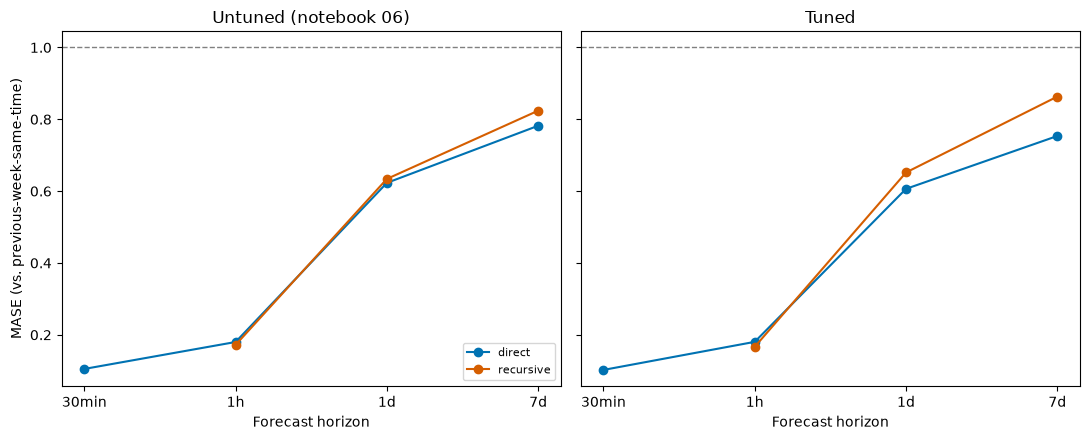

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
colors = {"direct": "#0072B2", "recursive": "#D55E00"}
horizon_names = list(config.HORIZONS)

for ax, tuned, title in zip(axes, [False, True], ["Untuned (notebook 06)", "Tuned"]):
    for strategy, color in colors.items():
        xs, ys = [], []
        for h in horizon_names:
            key = (h, strategy)
            if tuned and key in results.index:
                xs.append(h); ys.append(results.loc[key, "mase"])
            elif not tuned and key in untuned_mase:
                xs.append(h); ys.append(untuned_mase[key])
        ax.plot(xs, ys, marker="o", label=strategy, color=color)
    ax.axhline(1.0, color="grey", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Forecast horizon")

axes[0].set_ylabel("MASE (vs. previous-week-same-time)")
axes[0].legend(fontsize=8)
fig.tight_layout()

## Bias and tail error (P95), tuned models

In [8]:
results[["bias", "p95_abs_error"]]

bias  p95_abs_error
horizon strategy                         
1d      direct     -55.697       3416.441
        recursive  -47.750       3631.394
1h      direct       2.798        993.825
        recursive   -2.431        908.937
30min   direct      -1.131        552.221
7d      direct    -116.097       4101.781
        recursive  -21.760       5133.458

## Bias and tail error tell a different story than MASE alone

Two things MASE hides, visible here:

- **`7d` direct is the most *biased* model** (bias ≈ -116 MW — consistently over-forecasting) despite having the *better* MASE of the two `7d` strategies. `7d` recursive is far less biased (≈ -22 MW) but has a fatter tail (P95 ≈ 5133 MW vs. ≈ 4102 MW) — its errors are more scattered rather than systematically skewed. Two models can have similar-looking accuracy for very different reasons, and MASE alone doesn't distinguish "consistently a bit off" from "occasionally very wrong."
- **P95 tail error moves opposite to MASE at `1h`**: recursive both wins on MASE *and* has a smaller tail error there (908.9 vs. 993.8) — a clean win, not just a marginal one.

Neither of these would have been visible from MAE/RMSE/MASE alone — worth carrying `bias` and a tail-error metric into Week 5's calibration work, where systematic skew and tail behaviour become the central question rather than a side note.

## Error distribution per scenario, VALIDATION

The metrics above (MAE, bias, P95) are all summaries of one underlying thing: the per-half-hour signed error (`actual - forecast`) over `VALIDATION`. Plotting the full distribution — not just its mean (`bias`) or its 95th percentile (`p95_abs_error`) — shows the shape those numbers were summarizing: is it a tight, symmetric bell, or something skewed with a long tail on one side?

Faceted by horizon (one panel each) rather than overlaid in a single axes, since the four horizons sit on very different MW scales (30min errors are two orders of magnitude tighter than 7d's) — a shared x-axis would flatten the shorter horizons to invisible spikes. `direct`/`recursive` share an axis within each horizon panel, where they *are* directly comparable, using this project's established colors (`#0072B2`/`#D55E00`, Okabe-Ito, consistent with every prior notebook).

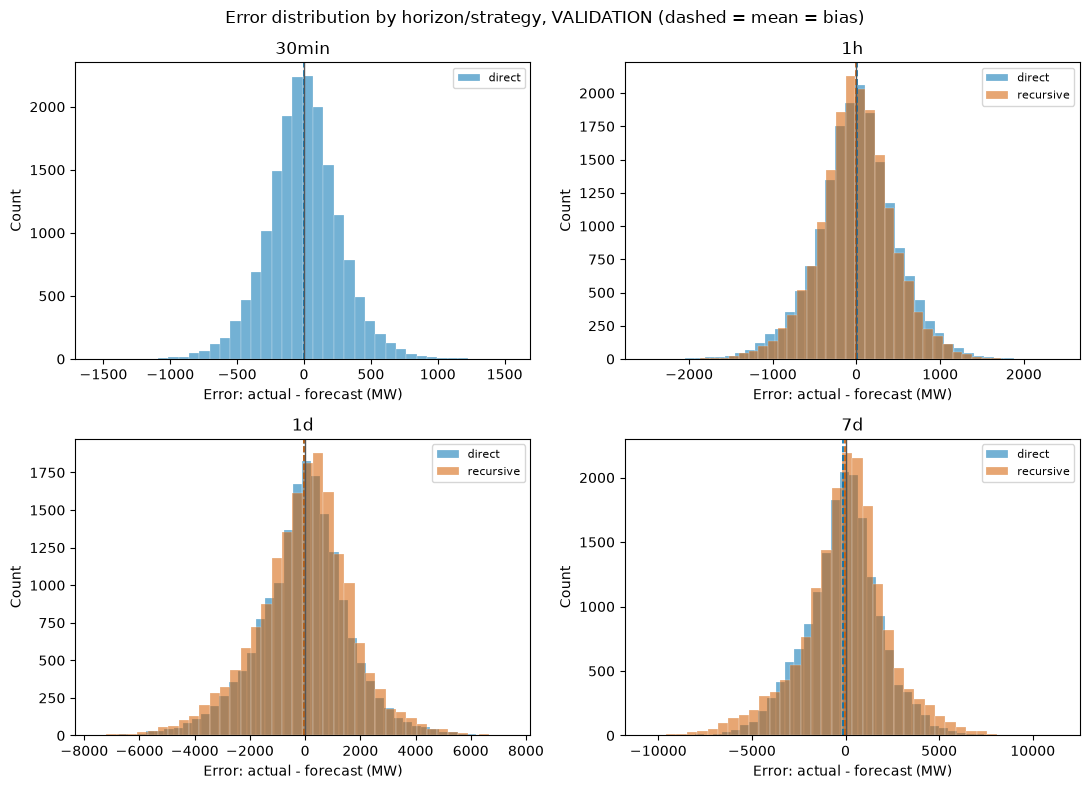

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
horizon_order = list(config.HORIZONS)

for ax, horizon_name in zip(axes.flat, horizon_order):
    for strategy, color in colors.items():
        key = (horizon_name, strategy)
        if key not in predictions_by_scenario:
            continue
        preds = predictions_by_scenario[key]
        errors = demand.loc[preds.index] - preds
        ax.hist(errors, bins=40, alpha=0.55, label=strategy, color=color, edgecolor="white", linewidth=0.3)
        ax.axvline(errors.mean(), color=color, linestyle="--", linewidth=1.2)
    ax.axvline(0, color="#555555", linewidth=1)
    ax.set_title(horizon_name)
    ax.set_xlabel("Error: actual - forecast (MW)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

fig.suptitle("Error distribution by horizon/strategy, VALIDATION (dashed = mean = bias)")
fig.tight_layout()